# Travel Analytics: Integrating Machine Learning and MLOps in Travel

**Author - Vivek Bankey**

## Project Summary

This project focuses on applying Data Analytics, Machine Learning, and MLOps techniques to travel and tourism data.

The project uses three datasets:

- Users
- Flights
- Hotels

The datasets provide information about users, flight journeys, flight prices, hotel bookings, travel destinations, and user travel behavior.

The overall project will eventually include:

1. Flight Price Prediction using Regression
2. Gender Classification
3. Hotel Recommendation System
4. REST API using Flask
5. Docker Containerization
6. Kubernetes Deployment
7. Apache Airflow Workflow Automation
8. Jenkins CI/CD Pipeline
9. MLflow Model Tracking
10. Streamlit Application

This notebook focuses on understanding the datasets and performing Exploratory Data Analysis (EDA) before developing the machine learning models.

## 1. Business Context

In the travel and tourism industry, data analytics and machine learning can be used to understand customer behavior, predict travel-related outcomes, and provide personalized travel recommendations.

This project combines user, flight, and hotel data to analyze travel patterns and preferences.

The analysis will serve as the foundation for developing machine learning solutions that can:

- Predict flight prices
- Classify users based on gender
- Recommend suitable hotels
- Support data-driven travel decisions

The project also aims to demonstrate how machine learning models can be integrated into a complete MLOps workflow for reliable deployment and automation.

## 2. Problem Statement

The travel datasets contain information about users, flights, and hotels, but this information needs to be analyzed systematically to identify useful patterns and relationships.

The main analytical problems addressed in this project are:

1. Understanding user demographics and travel behavior.
2. Identifying factors associated with flight prices.
3. Building a regression model to predict flight prices.
4. Developing a classification model for gender prediction.
5. Developing a hotel recommendation system based on user preferences and historical travel information.
6. Preparing the machine learning solutions for deployment through an MLOps pipeline.

## 3. Project Objectives

### Machine Learning Objectives

- Perform exploratory data analysis on users, flights, and hotels datasets.
- Build a regression model for flight price prediction.
- Build a classification model for gender classification.
- Develop a hotel recommendation system.

### MLOps Objectives

- Track experiments and models using MLflow.
- Develop a REST API using Flask.
- Containerize the application using Docker.
- Deploy the application using Kubernetes.
- Automate workflows using Apache Airflow.
- Implement CI/CD using Jenkins.
- Develop an interactive Streamlit application.

### Documentation Objectives

- Maintain clean and organized code.
- Maintain a structured GitHub repository.
- Document methodology, results, and deployment procedures.
- Prepare a professional project report and presentation.

## 4. Dataset Description

The project uses three datasets: Users, Flights, and Hotels.

### 4.1 Users Dataset

The Users dataset contains information about travelers.

| Column | Description |
|---|---|
| code | User identifier |
| company | Associated company |
| name | Name of the user |
| gender | Gender of the user |
| age | Age of the user |

### 4.2 Flights Dataset

The Flights dataset contains information about flight journeys.

| Column | Description |
|---|---|
| travelCode | Travel identifier |
| userCode | User identifier |
| from | Origin |
| to | Destination |
| flightType | Type of flight |
| price | Flight price |
| time | Flight duration |
| distance | Flight distance |
| agency | Flight agency |
| date | Flight date |

### 4.3 Hotels Dataset

The Hotels dataset contains information about hotel bookings.

| Column | Description |
|---|---|
| travelCode | Travel identifier |
| userCode | User identifier |
| name | Hotel name |
| place | Hotel location |
| days | Number of days |
| price | Price per day |
| total | Total hotel price |
| date | Hotel booking date |

In [3]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# ============================================
# LOAD DATASETS
# ============================================

users = pd.read_csv("../data/users.csv")
flights = pd.read_csv("../data/flights.csv")
hotels = pd.read_csv("../data/hotels.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [5]:
# Dataset value count(Shape of dataset)

print("Users Dataset   :", users.shape)
print("Flights Dataset :", flights.shape)
print("Hotels Dataset  :", hotels.shape)

Users Dataset   : (1340, 5)
Flights Dataset : (271888, 10)
Hotels Dataset  : (40552, 8)


In [6]:
print("USERS")
display(users.head())

print("\nFLIGHTS")
display(flights.head())

print("\nHOTELS")
display(hotels.head())

USERS


,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44



FLIGHTS


,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019



HOTELS


,travelCode,userCode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019


In [7]:
print("========== USERS ==========")
users.info()

print("\n========== FLIGHTS ==========")
flights.info()

print("\n========== HOTELS ==========")
hotels.info()

========== USERS ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   code     1340 non-null   int64 
 1   company  1340 non-null   object
 2   name     1340 non-null   object
 3   gender   1340 non-null   object
 4   age      1340 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 52.5+ KB

========== FLIGHTS ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   travelCode  271888 non-null  int64  
 1   userCode    271888 non-null  int64  
 2   from        271888 non-null  object 
 3   to          271888 non-null  object 
 4   flightType  271888 non-null  object 
 5   price       271888 non-null  float64
 6   time        271888 non-null  float64
 7   distance    271888 non-null  fl

In [8]:
print("Missing Values - Users")
display(users.isnull().sum().to_frame("Missing Values"))

print("\nMissing Values - Flights")
display(flights.isnull().sum().to_frame("Missing Values"))

print("\nMissing Values - Hotels")
display(hotels.isnull().sum().to_frame("Missing Values"))

Missing Values - Users


,Missing Values
code,0
company,0
name,0
gender,0
age,0



Missing Values - Flights


,Missing Values
travelCode,0
userCode,0
from,0
to,0
flightType,0
price,0
time,0
distance,0
agency,0
date,0



Missing Values - Hotels


,Missing Values
travelCode,0
userCode,0
name,0
place,0
days,0
price,0
total,0
date,0


In [9]:
print("Users duplicates   :", users.duplicated().sum())
print("Flights duplicates :", flights.duplicated().sum())
print("Hotels duplicates  :", hotels.duplicated().sum())

Users duplicates   : 0
Flights duplicates : 0
Hotels duplicates  : 0


## 5. Statistical Summary

Statistical summaries are used to understand the central tendency, dispersion, and distribution of numerical variables in the datasets.

In [10]:
# Statistical summary of numerical variables

print("========== USERS ==========")
display(users.describe())

print("\n========== FLIGHTS ==========")
display(flights.describe())

print("\n========== HOTELS ==========")
display(hotels.describe())

========== USERS ==========


,code,age
count,1340.000000,1340.000000
mean,669.500000,42.742537
std,386.968991,12.869779
min,0.000000,21.000000
25%,334.750000,32.000000
50%,669.500000,42.000000
75%,1004.250000,54.000000
max,1339.000000,65.000000



========== FLIGHTS ==========


,travelCode,userCode,price,time,distance
count,271888.000000,271888.000000,271888.00000,271888.000000,271888.000000
mean,67971.500000,667.505495,957.37503,1.421147,546.955535
std,39243.724665,389.523127,362.31189,0.542541,208.851288
min,0.000000,0.000000,301.51000,0.440000,168.220000
25%,33985.750000,326.000000,672.66000,1.040000,401.660000
50%,67971.500000,659.000000,904.00000,1.460000,562.140000
75%,101957.250000,1011.000000,1222.24000,1.760000,676.530000
max,135943.000000,1339.000000,1754.17000,2.440000,937.770000



========== HOTELS ==========


,travelCode,userCode,days,price,total
count,40552.000000,40552.000000,40552.000000,40552.000000,40552.000000
mean,67911.794461,666.963726,2.499679,214.439554,536.229513
std,39408.199333,391.136794,1.119326,76.742305,319.331482
min,0.000000,0.000000,1.000000,60.390000,60.390000
25%,33696.750000,323.000000,1.000000,165.990000,247.620000
50%,67831.000000,658.000000,2.000000,242.880000,495.240000
75%,102211.250000,1013.000000,4.000000,263.410000,742.860000
max,135942.000000,1339.000000,4.000000,313.020000,1252.080000


## 6. Categorical Variable Analysis

Categorical variables are analyzed to understand the number of unique categories and their frequency distribution.

In [11]:
# Categorical columns and number of unique values

print("========== USERS ==========")

print("Company:")
display(users["company"].value_counts().head(10))

print("Gender:")
display(users["gender"].value_counts())


print("\n========== FLIGHTS ==========")

print("From:")
display(flights["from"].value_counts().head(10))

print("To:")
display(flights["to"].value_counts().head(10))

print("Flight Type:")
display(flights["flightType"].value_counts())

print("Agency:")
display(flights["agency"].value_counts())


print("\n========== HOTELS ==========")

print("Hotel:")
display(hotels["name"].value_counts().head(10))

print("Place:")
display(hotels["place"].value_counts().head(10))

========== USERS ==========
Company:


company
4You             453
Acme Factory     261
Wonka Company    237
Monsters CYA     195
Umbrella LTDA    194
Name: count, dtype: int64

Gender:


gender
male      452
female    448
none      440
Name: count, dtype: int64


========== FLIGHTS ==========
From:


...

agency
Rainbow        116752
CloudFy        116378
FlyingDrops     38758
Name: count, dtype: int64


========== HOTELS ==========
Hotel:


name
Hotel K     5094
Hotel CB    5029
Hotel BD    4829
Hotel AF    4828
Hotel AU    4467
Hotel BP    4437
Hotel BW    4333
Hotel Z     4205
Hotel A     3330
Name: count, dtype: int64

Place:


place
Salvador (BH)          5094
Rio de Janeiro (RJ)    5029
Natal (RN)             4829
Sao Paulo (SP)         4828
Recife (PE)            4467
Brasilia (DF)          4437
Campo Grande (MS)      4333
Aracaju (SE)           4205
Florianopolis (SC)     3330
Name: count, dtype: int64

## 7. Unique Value Analysis

The number of unique values in each column is examined to identify categorical variables, identifiers, and variables with high cardinality.

In [12]:
# Number of unique values in each column

print("========== USERS ==========")
display(users.nunique().sort_values(ascending=False).to_frame("Unique Values"))

print("\n========== FLIGHTS ==========")
display(flights.nunique().sort_values(ascending=False).to_frame("Unique Values"))

print("\n========== HOTELS ==========")
display(hotels.nunique().sort_values(ascending=False).to_frame("Unique Values"))

========== USERS ==========


,Unique Values
code,1340
name,1338
age,45
company,5
gender,3



========== FLIGHTS ==========


,Unique Values
travelCode,135944
userCode,1335
date,999
price,490
distance,35
time,33
from,9
to,9
flightType,3
agency,3



========== HOTELS ==========


,Unique Values
travelCode,40552
userCode,1310
date,199
total,36
place,9
name,9
price,9
days,4


## 8. Date Analysis

The flight and hotel booking dates are converted into datetime format so that temporal patterns such as year, month, day, and day of the week can be analyzed.

In [13]:
# Convert date columns to datetime

flights["date"] = pd.to_datetime(flights["date"])
hotels["date"] = pd.to_datetime(hotels["date"])

print("Flight date type :", flights["date"].dtype)
print("Hotel date type  :", hotels["date"].dtype)

Flight date type : datetime64[ns]
Hotel date type  : datetime64[ns]


In [14]:
# Extract useful date features

flights["year"] = flights["date"].dt.year
flights["month"] = flights["date"].dt.month
flights["day"] = flights["date"].dt.day
flights["day_of_week"] = flights["date"].dt.dayofweek

hotels["year"] = hotels["date"].dt.year
hotels["month"] = hotels["date"].dt.month
hotels["day"] = hotels["date"].dt.day
hotels["day_of_week"] = hotels["date"].dt.dayofweek

In [15]:
display(flights[["date", "year", "month", "day", "day_of_week"]].head())

,date,year,month,day,day_of_week
0,2019-09-26,2019,9,26,3
1,2019-09-30,2019,9,30,0
2,2019-10-03,2019,10,3,3
3,2019-10-04,2019,10,4,4
4,2019-10-10,2019,10,10,3


# 9. Users Dataset — Exploratory Data Analysis

The Users dataset is analyzed to understand traveler demographics and user characteristics.

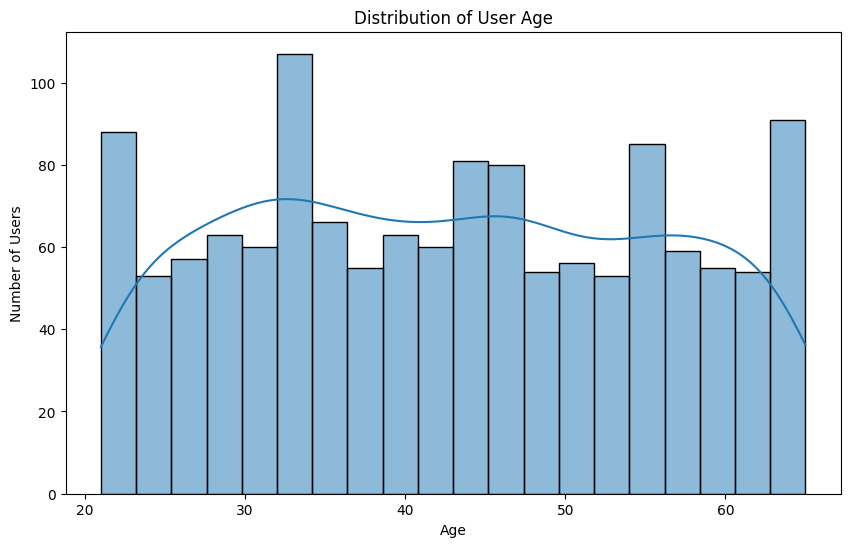

In [16]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=users,
    x="age",
    bins=20,
    kde=True
)

plt.title("Distribution of User Age")
plt.xlabel("Age")
plt.ylabel("Number of Users")

plt.show()

**Gender Distribution**

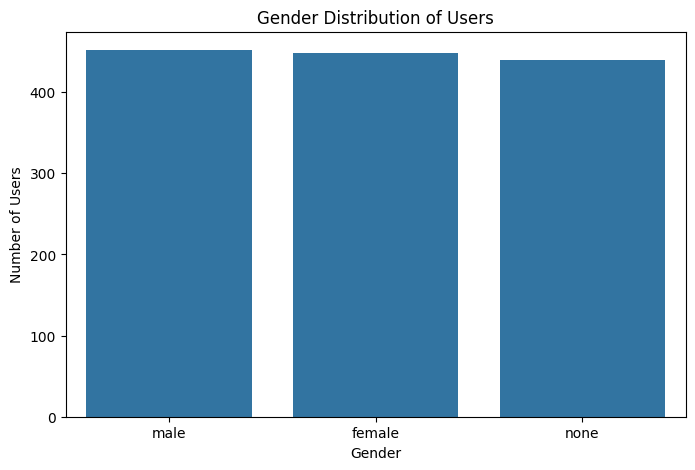

In [17]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=users,
    x="gender"
)

plt.title("Gender Distribution of Users")
plt.xlabel("Gender")
plt.ylabel("Number of Users")

plt.show()

**Age Vs Gender**

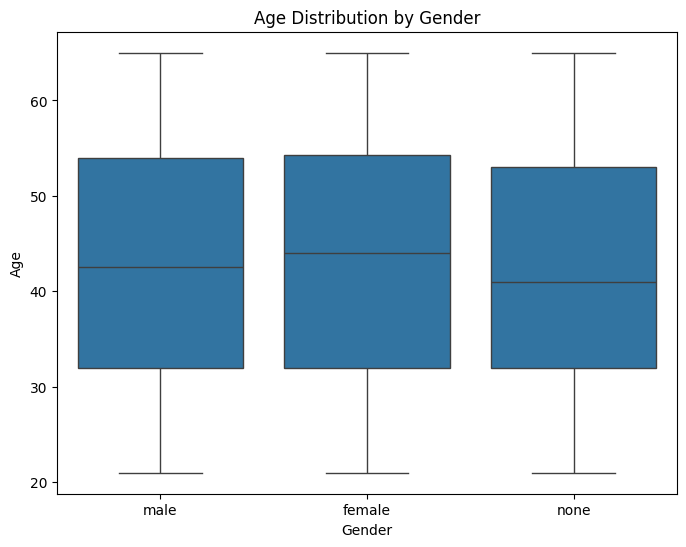

In [18]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=users,
    x="gender",
    y="age"
)

plt.title("Age Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Age")

plt.show()

**Company Distribution**

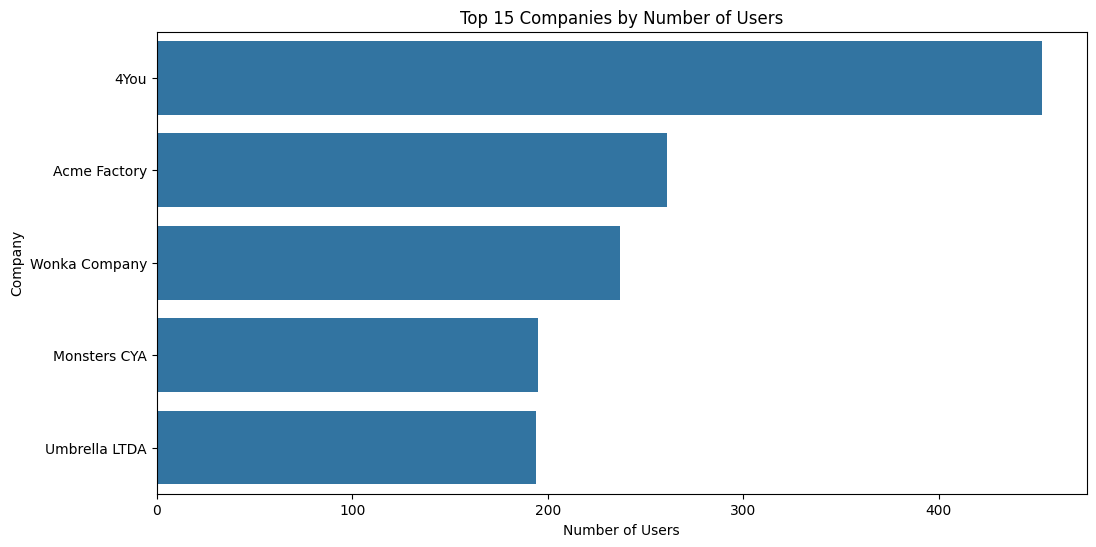

In [19]:
company_counts = users["company"].value_counts().head(15)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=company_counts.values,
    y=company_counts.index
)

plt.title("Top 15 Companies by Number of Users")
plt.xlabel("Number of Users")
plt.ylabel("Company")

plt.show()

# 10. Flights Dataset — Exploratory Data Analysis

The Flights dataset contains information about travel journeys, including origin, destination, flight type, price, duration, distance, agency, and travel date.

The objective of this analysis is to understand the distribution of flight prices and identify relationships between flight price and other variables.

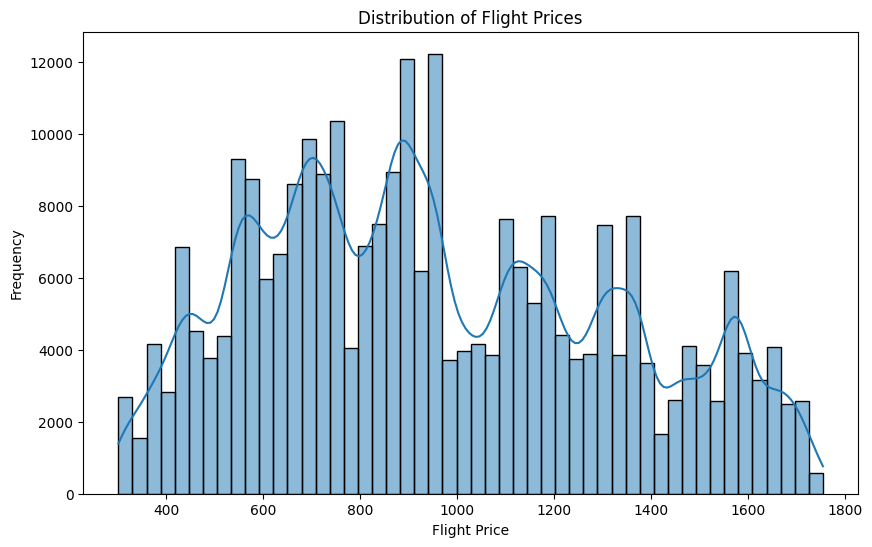

In [20]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=flights,
    x="price",
    bins=50,
    kde=True
)

plt.title("Distribution of Flight Prices")
plt.xlabel("Flight Price")
plt.ylabel("Frequency")

plt.show()

In [21]:
flights["price"].describe()

count    271888.00000
mean        957.37503
std         362.31189
min         301.51000
25%         672.66000
50%         904.00000
75%        1222.24000
max        1754.17000
Name: price, dtype: float64

**Flight Distribution**

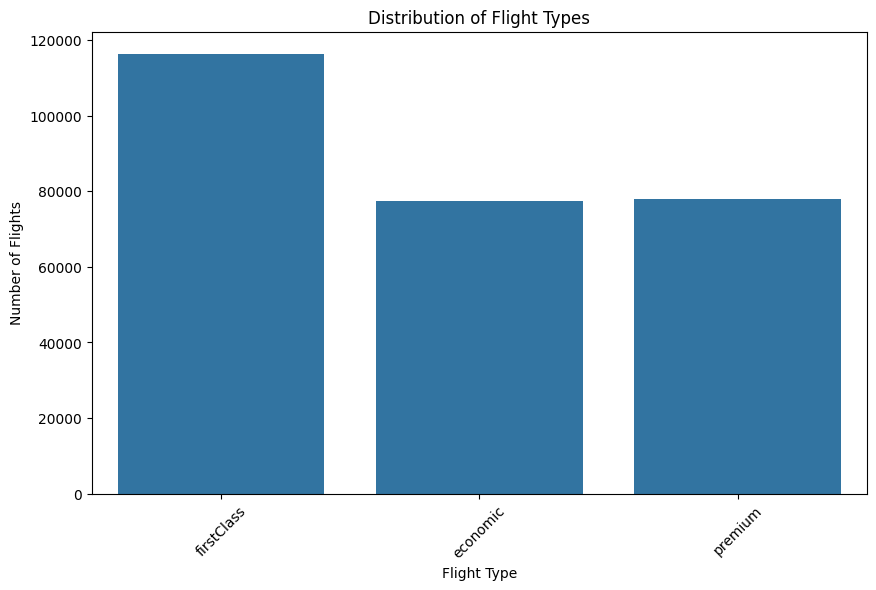

In [22]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=flights,
    x="flightType"
)

plt.title("Distribution of Flight Types")
plt.xlabel("Flight Type")
plt.ylabel("Number of Flights")

plt.xticks(rotation=45)

plt.show()

**Flight Type Vs Price**

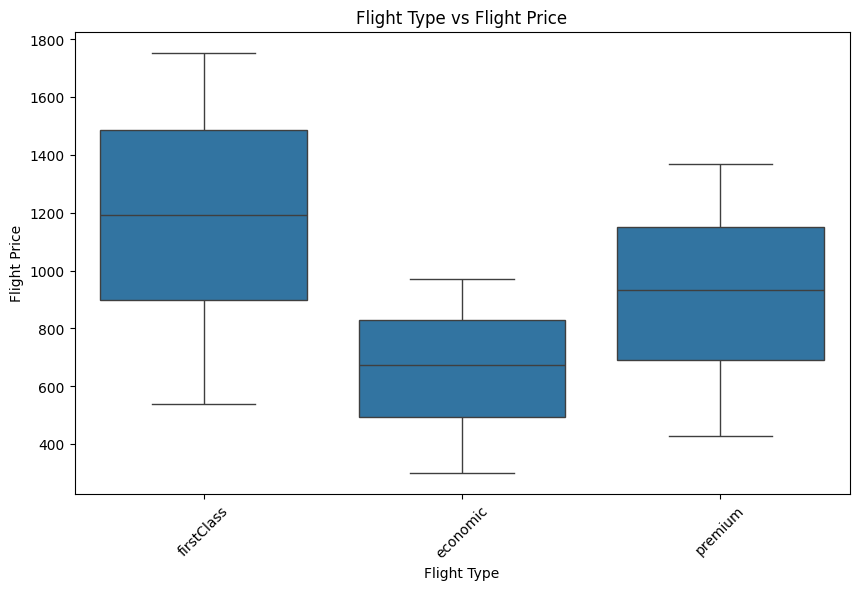

In [23]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=flights,
    x="flightType",
    y="price"
)

plt.title("Flight Type vs Flight Price")
plt.xlabel("Flight Type")
plt.ylabel("Flight Price")

plt.xticks(rotation=45)

plt.show()

**Distance Distribution**

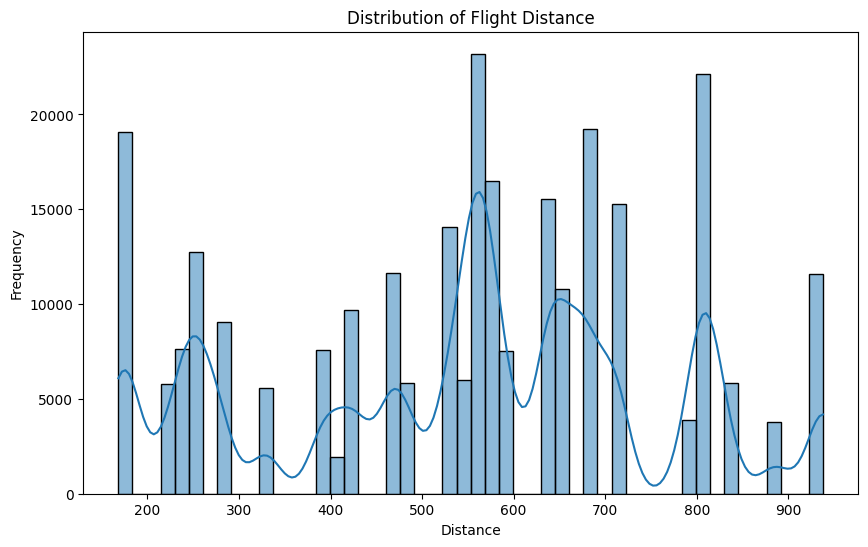

In [24]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=flights,
    x="distance",
    bins=50,
    kde=True
)

plt.title("Distribution of Flight Distance")
plt.xlabel("Distance")
plt.ylabel("Frequency")

plt.show()

**Distance vs Price**

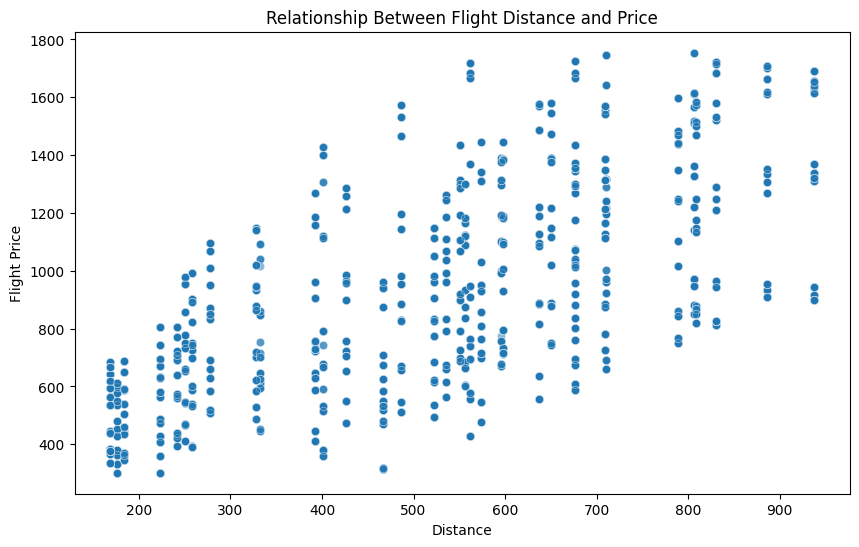

In [25]:
flight_sample = flights.sample(
    n=min(10000, len(flights)),
    random_state=42
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=flight_sample,
    x="distance",
    y="price",
    alpha=0.5
)

plt.title("Relationship Between Flight Distance and Price")
plt.xlabel("Distance")
plt.ylabel("Flight Price")

plt.show()


**Flight Duration vs Price**

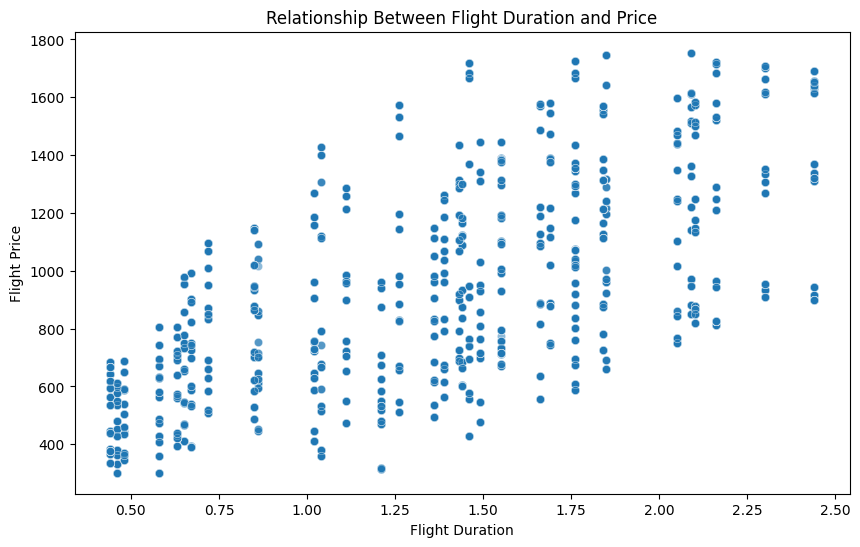

In [26]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=flight_sample,
    x="time",
    y="price",
    alpha=0.5
)

plt.title("Relationship Between Flight Duration and Price")
plt.xlabel("Flight Duration")
plt.ylabel("Flight Price")

plt.show()

**Correlation Analysis**

In [27]:
numeric_cols = [
    "price",
    "time",
    "distance"
]

correlation_matrix = flights[numeric_cols].corr()

display(correlation_matrix)

,price,time,distance
price,1.000000,0.64180,0.641915
time,0.641800,1.00000,0.999990
distance,0.641915,0.99999,1.000000


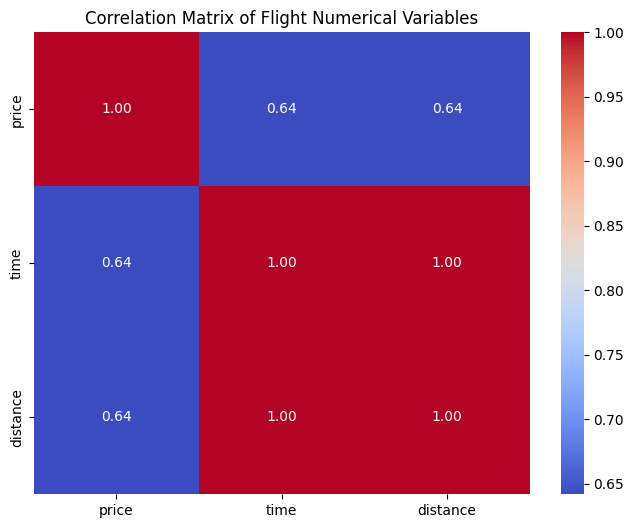

In [28]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Flight Numerical Variables")

plt.show()

**Agency Distribution**

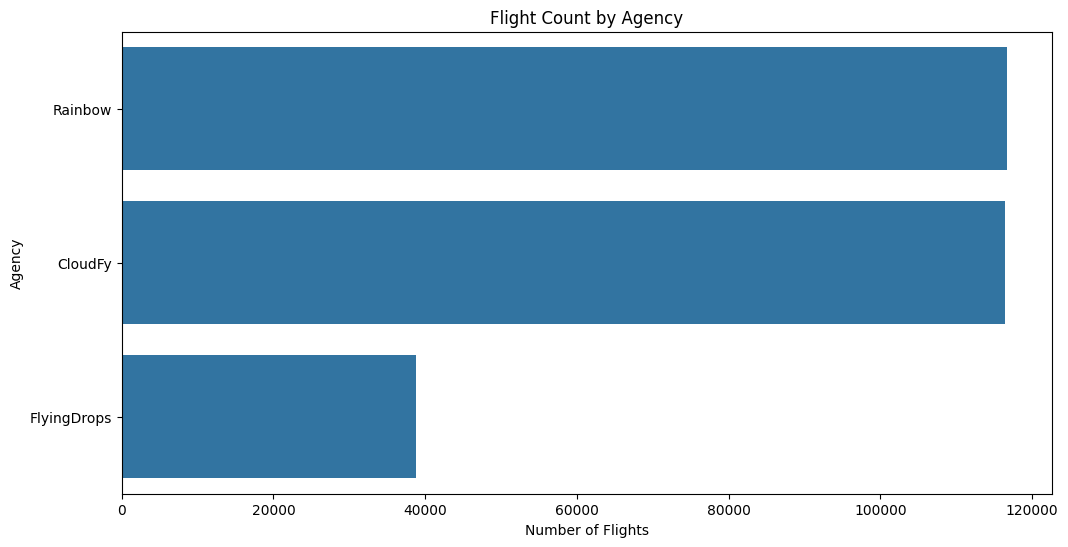

In [29]:
agency_counts = flights["agency"].value_counts()

plt.figure(figsize=(12, 6))

sns.barplot(
    x=agency_counts.values,
    y=agency_counts.index
)

plt.title("Flight Count by Agency")
plt.xlabel("Number of Flights")
plt.ylabel("Agency")

plt.show()

**Agency vs Price**

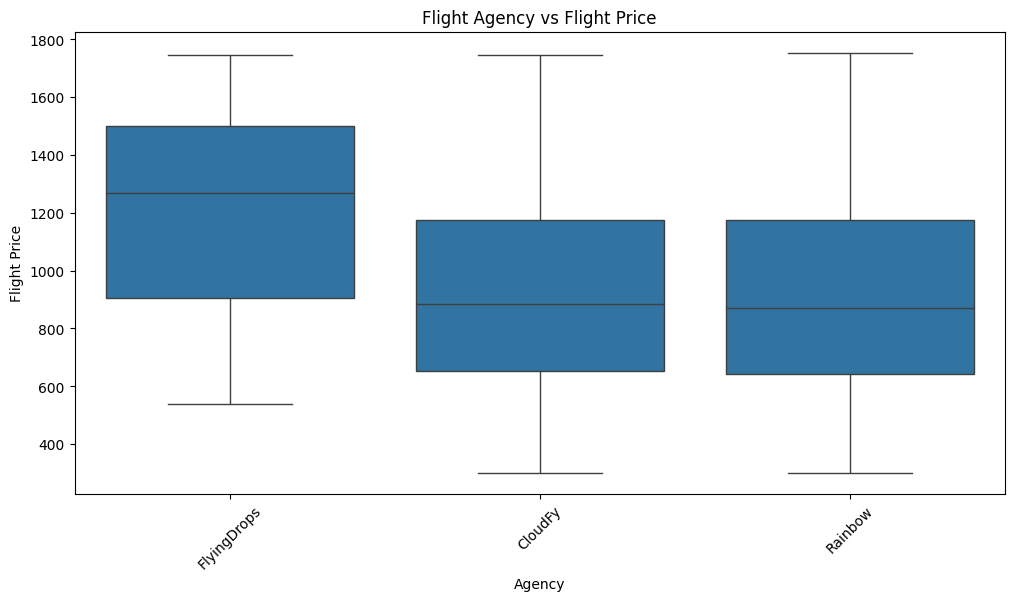

In [30]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=flights,
    x="agency",
    y="price"
)

plt.title("Flight Agency vs Flight Price")
plt.xlabel("Agency")
plt.ylabel("Flight Price")

plt.xticks(rotation=45)

plt.show()

**Top Origins**

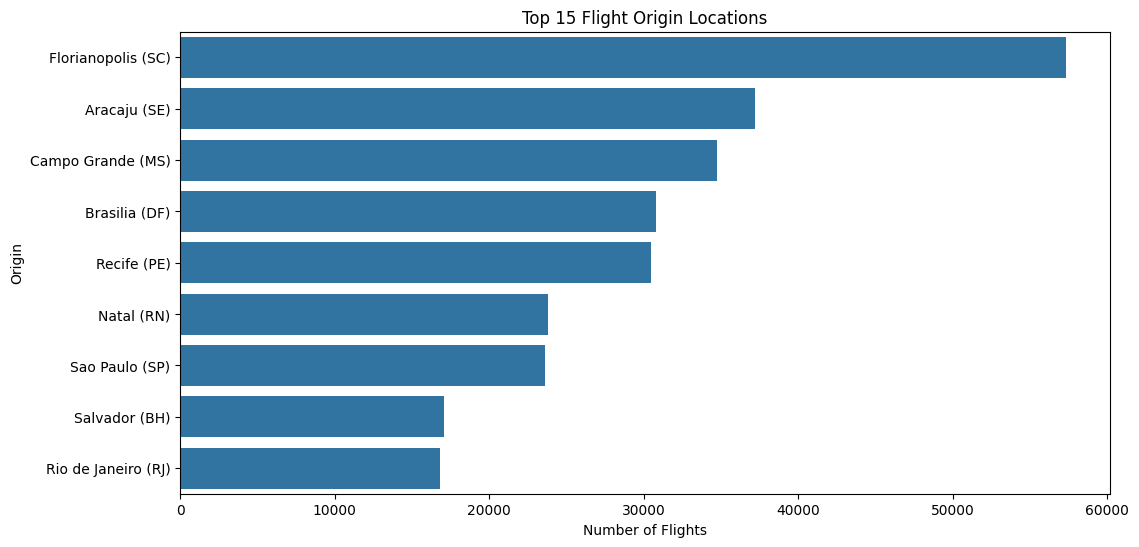

In [31]:
top_origins = flights["from"].value_counts().head(15)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_origins.values,
    y=top_origins.index
)

plt.title("Top 15 Flight Origin Locations")
plt.xlabel("Number of Flights")
plt.ylabel("Origin")

plt.show()

**Top Destination**

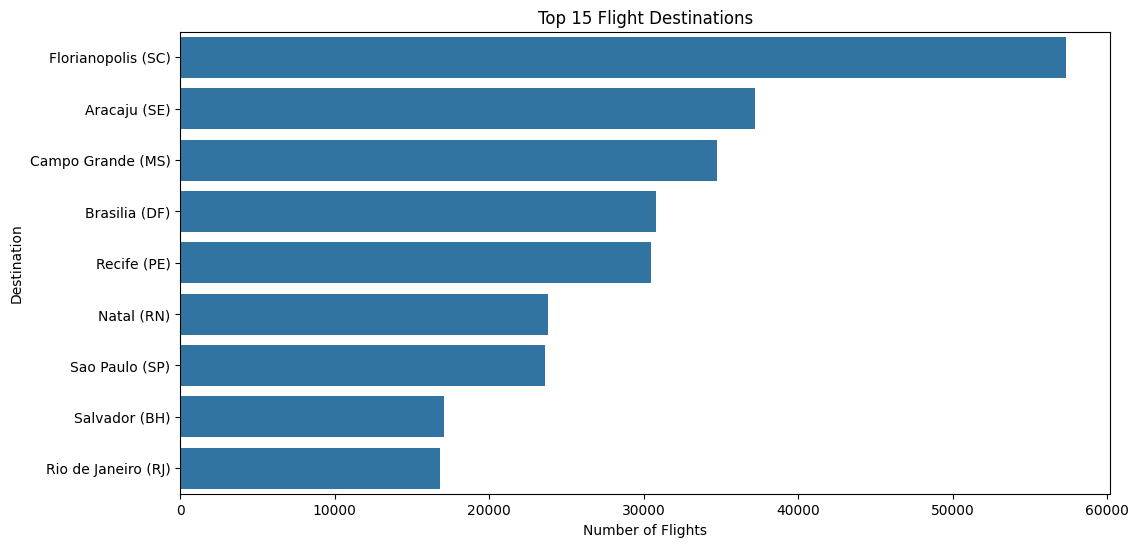

In [32]:
top_destinations = flights["to"].value_counts().head(15)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_destinations.values,
    y=top_destinations.index
)

plt.title("Top 15 Flight Destinations")
plt.xlabel("Number of Flights")
plt.ylabel("Destination")

plt.show()

**Monthly Flight Volume**

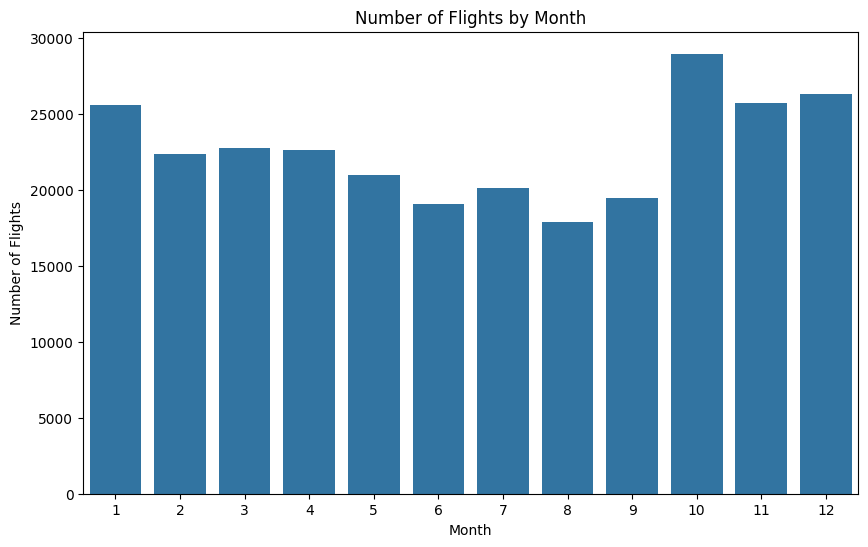

In [33]:
monthly_flights = (
    flights
    .groupby("month")
    .size()
    .reset_index(name="flight_count")
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=monthly_flights,
    x="month",
    y="flight_count"
)

plt.title("Number of Flights by Month")
plt.xlabel("Month")
plt.ylabel("Number of Flights")

plt.show()

**Monthly Average Price**

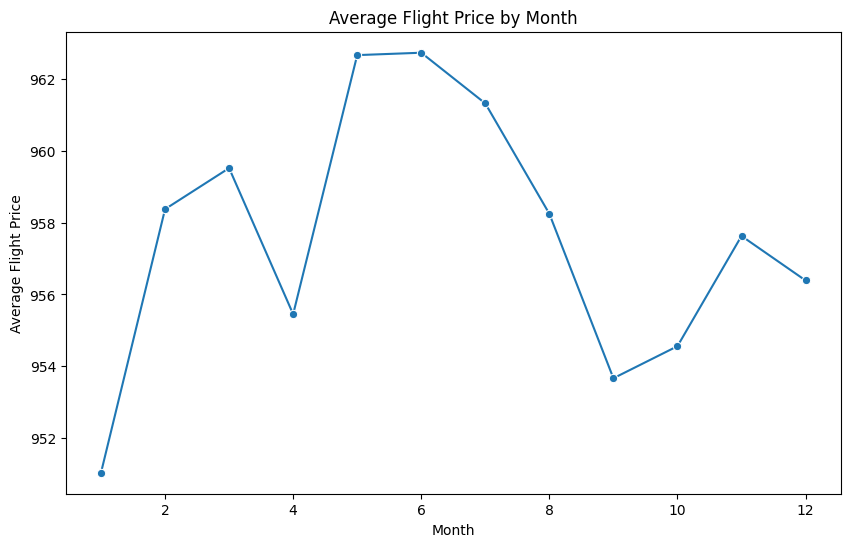

In [34]:
monthly_price = (
    flights
    .groupby("month")["price"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=monthly_price,
    x="month",
    y="price",
    marker="o"
)

plt.title("Average Flight Price by Month")
plt.xlabel("Month")
plt.ylabel("Average Flight Price")

plt.show()

**Day Of Week VS Price**

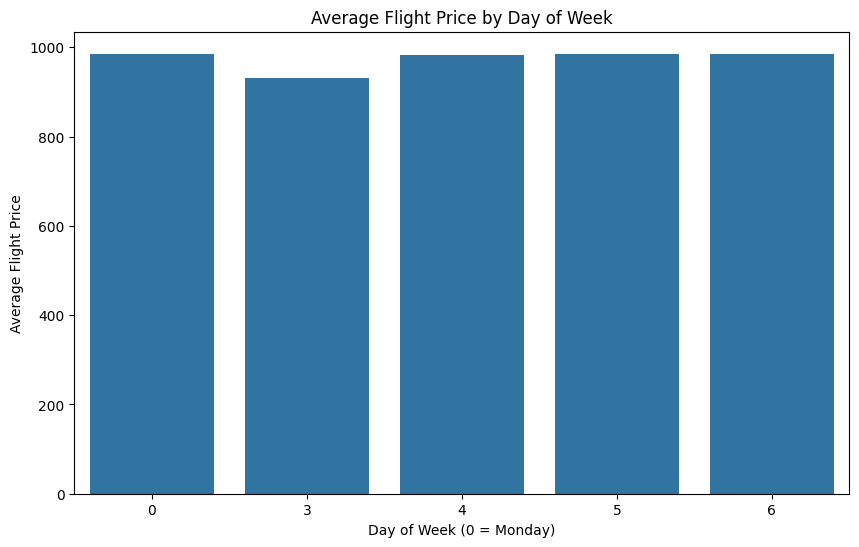

In [35]:
day_price = (
    flights
    .groupby("day_of_week")["price"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=day_price,
    x="day_of_week",
    y="price"
)

plt.title("Average Flight Price by Day of Week")
plt.xlabel("Day of Week (0 = Monday)")
plt.ylabel("Average Flight Price")

plt.show()

**Top 10 Expensive Routes**

In [36]:
route_analysis = (
    flights
    .groupby(["from", "to"])
    .agg(
        average_price=("price", "mean"),
        median_price=("price", "median"),
        number_of_flights=("price", "count")
    )
    .sort_values("average_price", ascending=False)
)

display(route_analysis.head(10))

,,average_price,median_price,number_of_flights
from,to,,,
Sao Paulo (SP),Florianopolis (SC),1380.881239,1370.17,6717
Campo Grande (MS),Rio de Janeiro (RJ),1371.030729,1363.27,2415
Brasilia (DF),Salvador (BH),1366.796635,1346.60,2009
Aracaju (SE),Salvador (BH),1364.968773,1289.05,2918
Rio de Janeiro (RJ),Recife (PE),1361.202604,1333.52,1897
Natal (RN),Salvador (BH),1357.972387,1315.97,926
Florianopolis (SC),Salvador (BH),1350.408472,1367.88,5800
Salvador (BH),Florianopolis (SC),1346.089441,1336.68,5800
Recife (PE),Rio de Janeiro (RJ),1341.604175,1351.89,1897


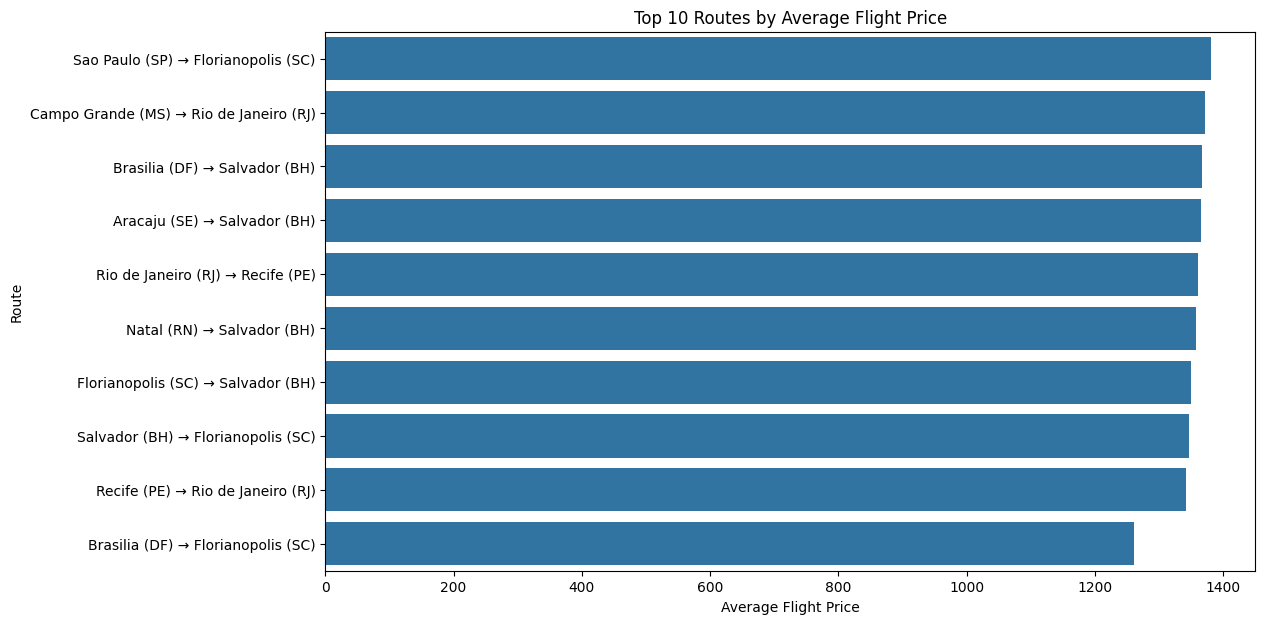

In [37]:
top_expensive_routes = (
    route_analysis
    .head(10)
    .reset_index()
)

top_expensive_routes["route"] = (
    top_expensive_routes["from"]
    + " → "
    + top_expensive_routes["to"]
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_expensive_routes,
    x="average_price",
    y="route"
)

plt.title("Top 10 Routes by Average Flight Price")
plt.xlabel("Average Flight Price")
plt.ylabel("Route")

plt.show()

# 11. Hotels Dataset — Exploratory Data Analysis

The Hotels dataset contains information about hotel bookings, including hotel name, location, length of stay, price per day, total booking price, user, and booking date.

The objective of this analysis is to understand hotel pricing patterns, customer stay behavior, popular hotel locations, and booking trends.

**Hotel Price Distribution**

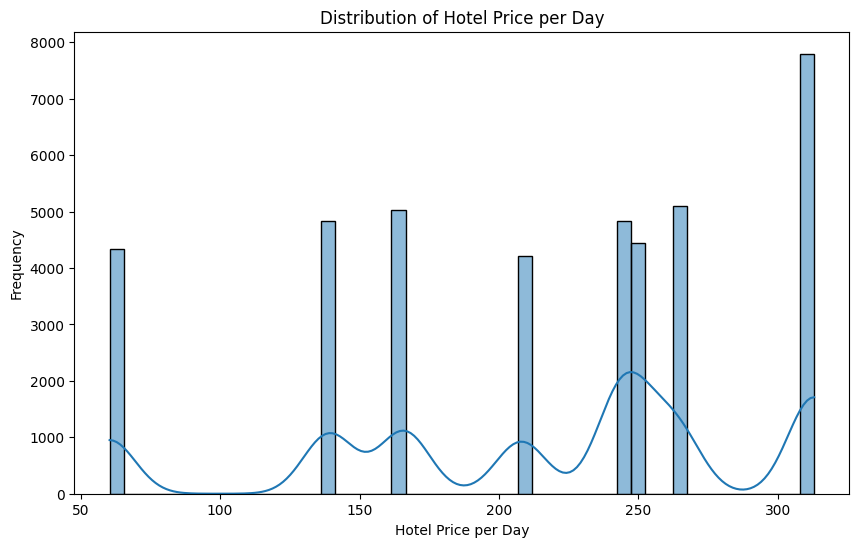

In [38]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=hotels,
    x="price",
    bins=50,
    kde=True
)

plt.title("Distribution of Hotel Price per Day")
plt.xlabel("Hotel Price per Day")
plt.ylabel("Frequency")

plt.show()

In [39]:
hotels["price"].describe()

count    40552.000000
mean       214.439554
std         76.742305
min         60.390000
25%        165.990000
50%        242.880000
75%        263.410000
max        313.020000
Name: price, dtype: float64

**Total Hotel Booking Price**

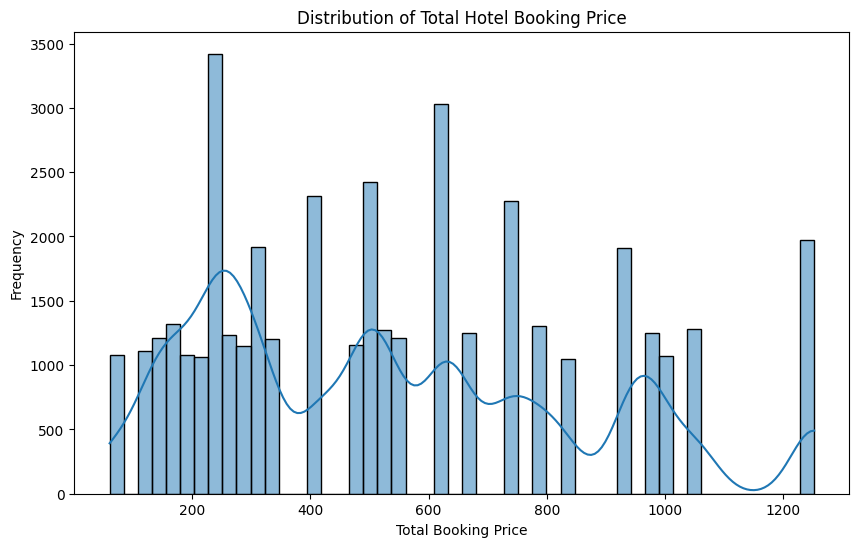

In [40]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=hotels,
    x="total",
    bins=50,
    kde=True
)

plt.title("Distribution of Total Hotel Booking Price")
plt.xlabel("Total Booking Price")
plt.ylabel("Frequency")

plt.show()

**Distribution of Hotel Stay Duration**

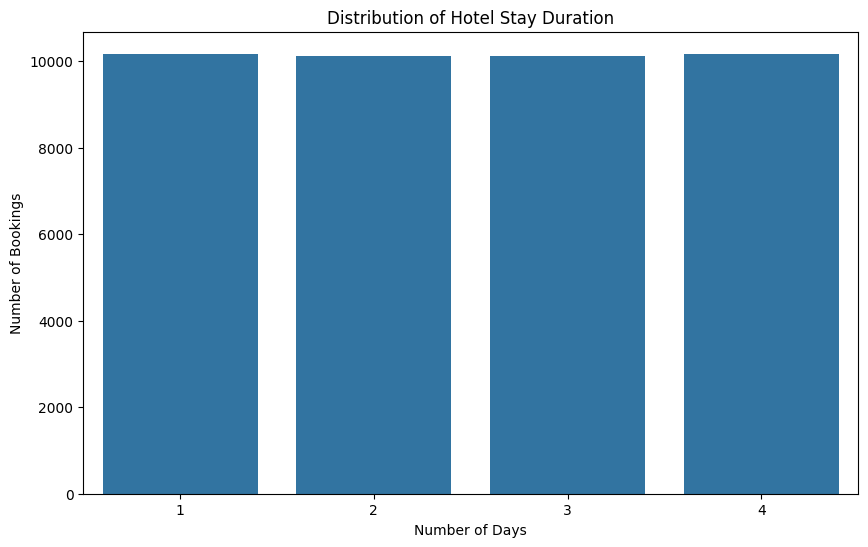

In [41]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=hotels,
    x="days"
)

plt.title("Distribution of Hotel Stay Duration")
plt.xlabel("Number of Days")
plt.ylabel("Number of Bookings")

plt.show()

**Stay Duration vs Total Hotel Price**

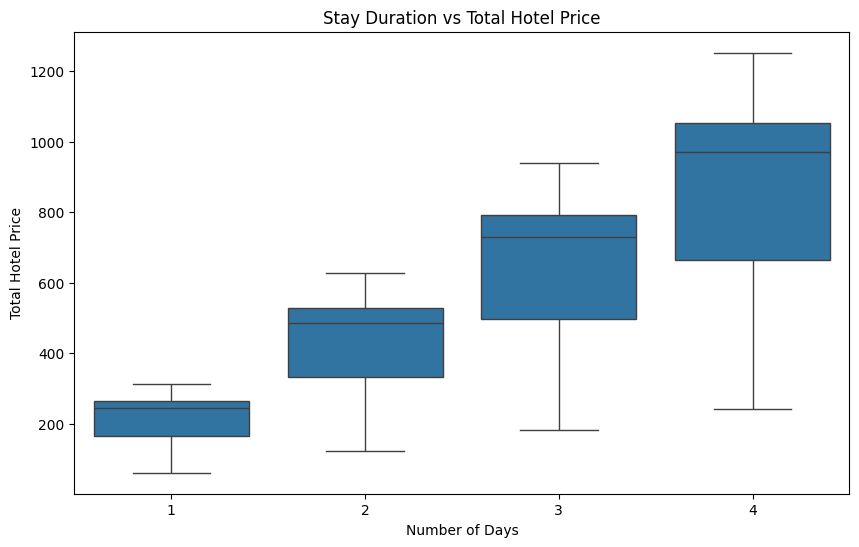

In [42]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=hotels,
    x="days",
    y="total"
)

plt.title("Stay Duration vs Total Hotel Price")
plt.xlabel("Number of Days")
plt.ylabel("Total Hotel Price")

plt.show()

**Hotel Price per Day vs Total Booking Price**

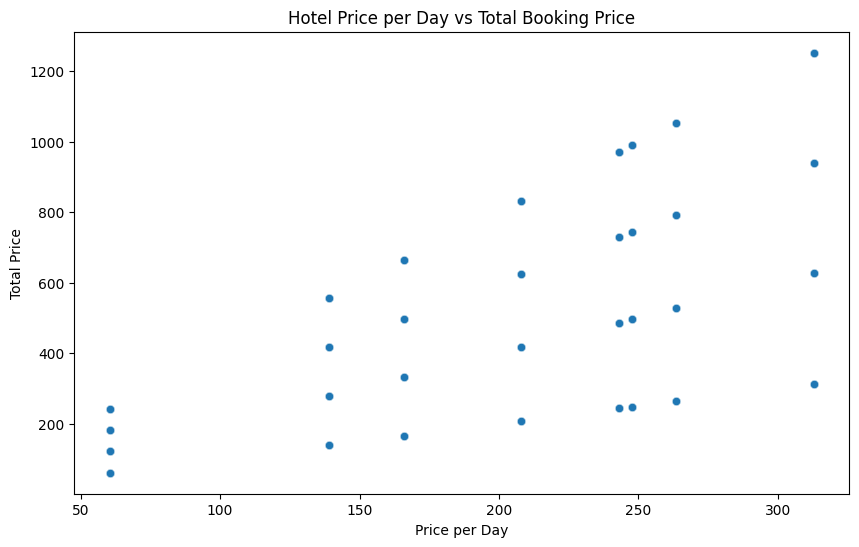

In [43]:
hotel_sample = hotels.sample(
    n=min(10000, len(hotels)),
    random_state=42
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=hotel_sample,
    x="price",
    y="total",
    alpha=0.5
)

plt.title("Hotel Price per Day vs Total Booking Price")
plt.xlabel("Price per Day")
plt.ylabel("Total Price")

plt.show()

**Hotel price correlation**

In [44]:
hotel_numeric_cols = [
    "days",
    "price",
    "total"
]

hotel_corr = hotels[hotel_numeric_cols].corr()

display(hotel_corr)

,days,price,total
days,1.000000,0.002321,0.75285
price,0.002321,1.000000,0.60273
total,0.752850,0.602730,1.00000


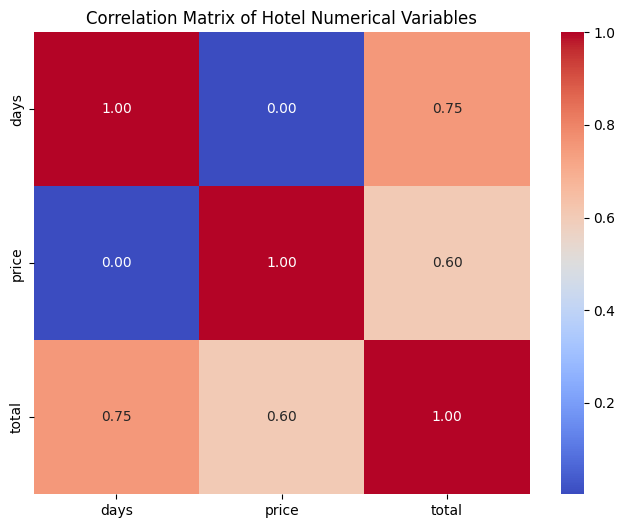

In [45]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    hotel_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Hotel Numerical Variables")

plt.show()

**Popular Hotels**

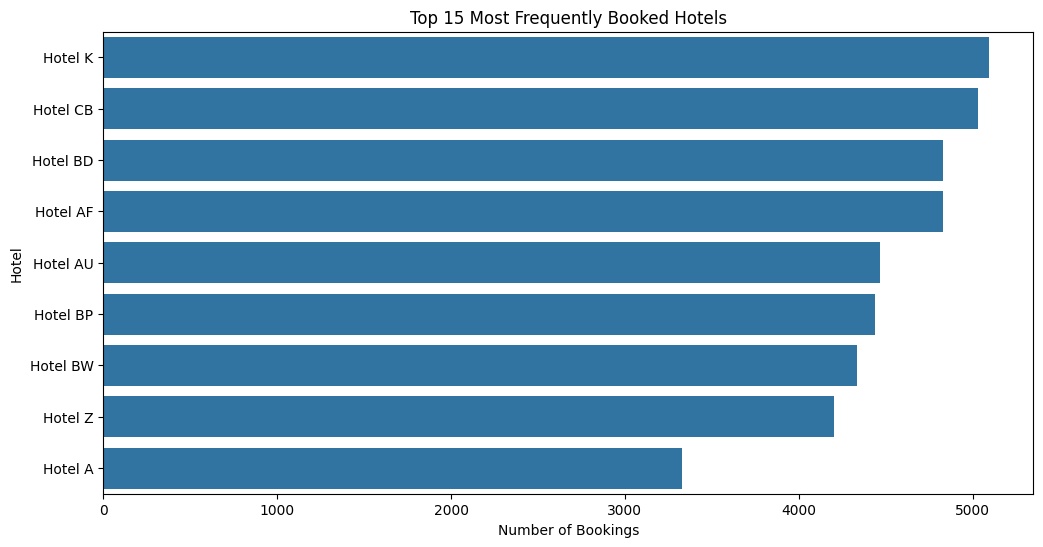

In [46]:
top_hotels = hotels["name"].value_counts().head(15)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_hotels.values,
    y=top_hotels.index
)

plt.title("Top 15 Most Frequently Booked Hotels")
plt.xlabel("Number of Bookings")
plt.ylabel("Hotel")

plt.show()

**Top 15 Hotel Locations by Number of Bookings**

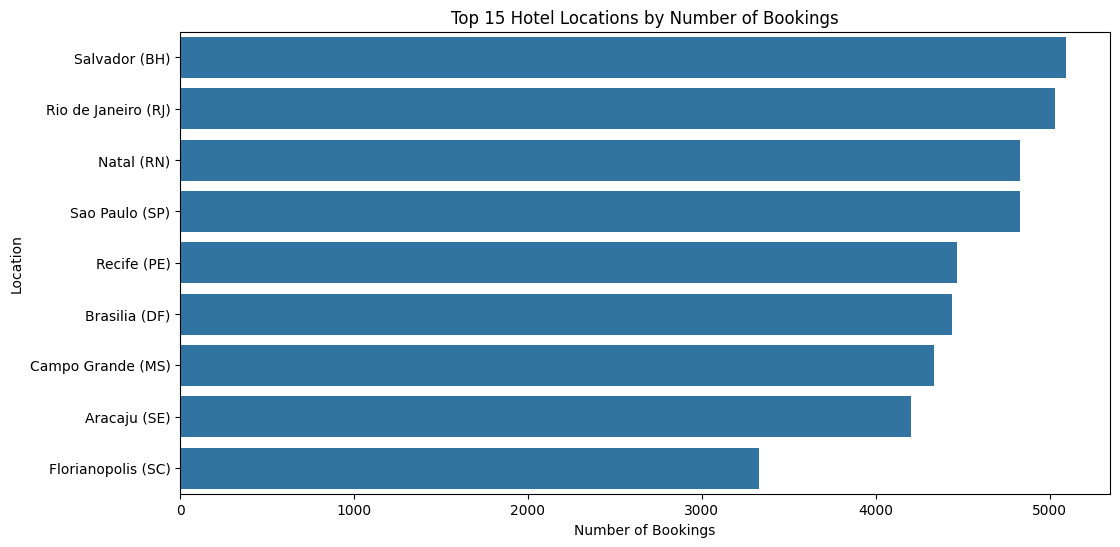

In [47]:
top_places = hotels["place"].value_counts().head(15)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_places.values,
    y=top_places.index
)

plt.title("Top 15 Hotel Locations by Number of Bookings")
plt.xlabel("Number of Bookings")
plt.ylabel("Location")

plt.show()

**Hotel Price per Day Across Popular Locations**

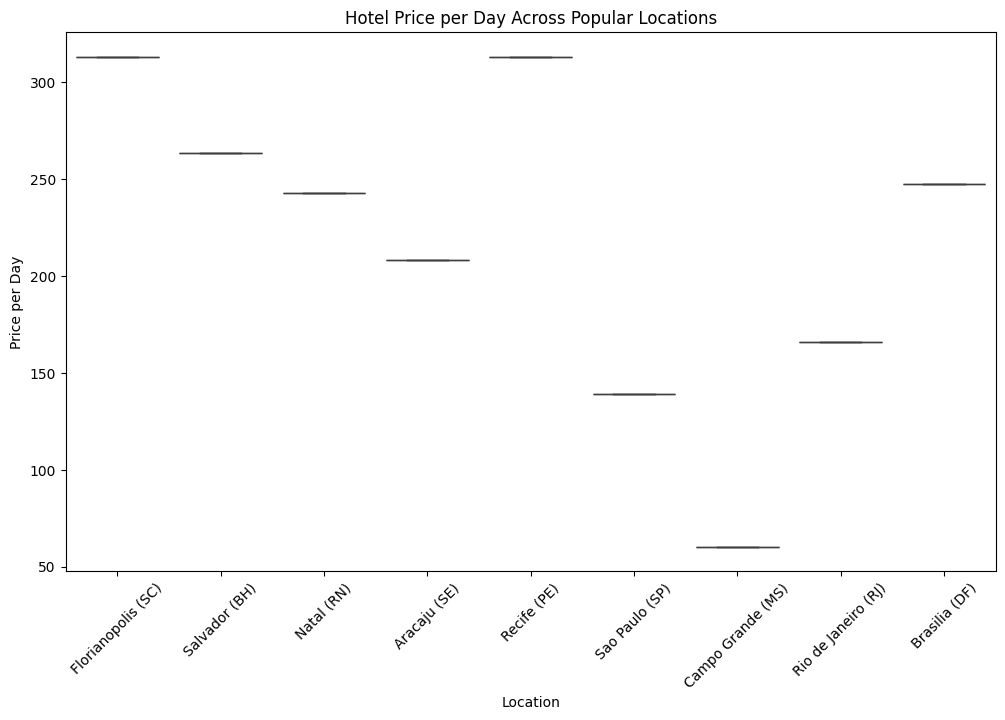

In [48]:
top_place_names = hotels["place"].value_counts().head(10).index

hotel_top_places = hotels[
    hotels["place"].isin(top_place_names)
]

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=hotel_top_places,
    x="place",
    y="price"
)

plt.title("Hotel Price per Day Across Popular Locations")
plt.xlabel("Location")
plt.ylabel("Price per Day")

plt.xticks(rotation=45)

plt.show()

**Number of Hotel Bookings by Month**

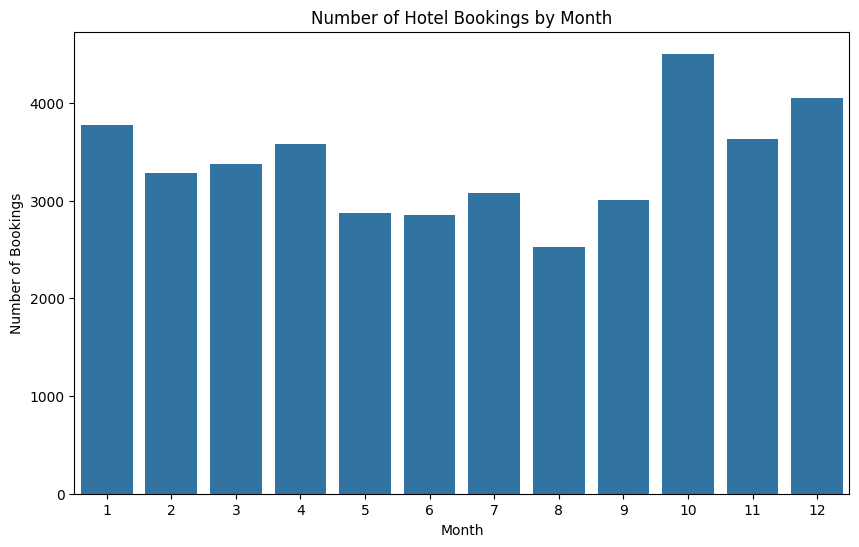

In [49]:
monthly_hotels = (
    hotels
    .groupby("month")
    .size()
    .reset_index(name="booking_count")
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=monthly_hotels,
    x="month",
    y="booking_count"
)

plt.title("Number of Hotel Bookings by Month")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")

plt.show()

**Average Hotel Price per Day by Month**

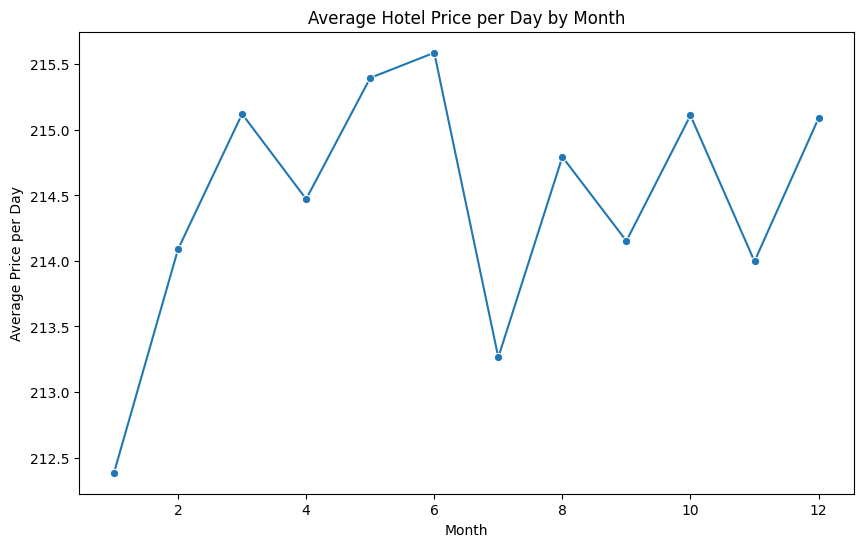

In [50]:
monthly_hotel_price = (
    hotels
    .groupby("month")["price"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=monthly_hotel_price,
    x="month",
    y="price",
    marker="o"
)

plt.title("Average Hotel Price per Day by Month")
plt.xlabel("Month")
plt.ylabel("Average Price per Day")

plt.show()

**Average Total Booking Cost by Stay Duration**

In [51]:
days_analysis = (
    hotels
    .groupby("days")
    .agg(
        average_price_per_day=("price", "mean"),
        average_total_price=("total", "mean"),
        bookings=("total", "count")
    )
    .reset_index()
)

display(days_analysis)

,days,average_price_per_day,average_total_price,bookings
0,1,213.891781,213.891781,10171
1,2,215.148302,430.296603,10110
2,3,213.875484,641.626451,10108
3,4,214.843724,859.374897,10163


**Stay Duration vs Average Total Cost**

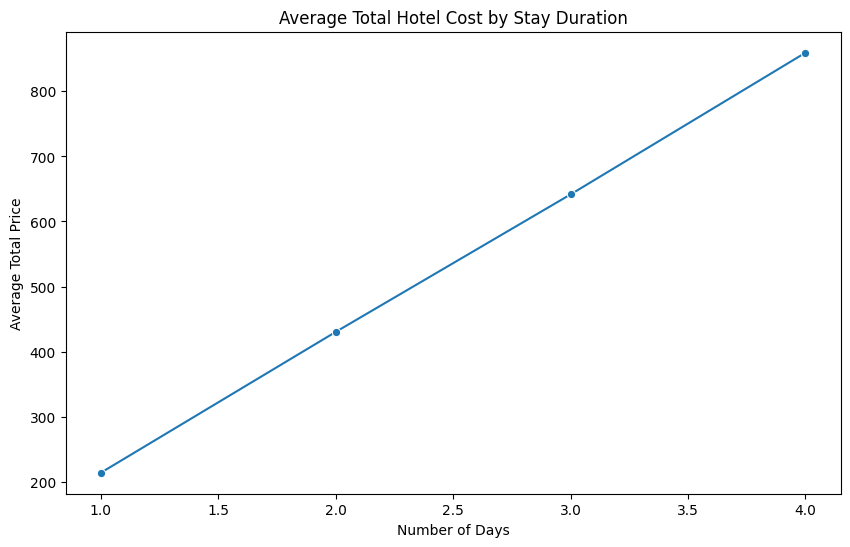

In [53]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=days_analysis,
    x="days",
    y="average_total_price",
    marker="o"
)

plt.title("Average Total Hotel Cost by Stay Duration")
plt.xlabel("Number of Days")
plt.ylabel("Average Total Price")

plt.show()

# 12. Dataset Relationship Analysis

The three datasets are connected through common identifiers.

- The Users dataset is connected to the Flights dataset through `users.code` and `flights.userCode`.
- The Users dataset is connected to the Hotels dataset through `users.code` and `hotels.userCode`.
- The Flights and Hotels datasets are connected through `travelCode` and `userCode`.

Understanding these relationships is important for combining travel information and developing future machine learning and recommendation models.

**Users → Flights relationship**

In [54]:
# Check whether flight user codes exist in the Users dataset

flight_user_match = flights["userCode"].isin(users["code"])

print("Flights with matching users:",
      flight_user_match.sum())

print("Flights with unmatched users:",
      (~flight_user_match).sum())

print("Matching percentage:",
      round(flight_user_match.mean() * 100, 2), "%")

Flights with matching users: 271888
Flights with unmatched users: 0
Matching percentage: 100.0 %


**Users → Hotels**

In [55]:
# Check whether hotel user codes exist in Users dataset

hotel_user_match = hotels["userCode"].isin(users["code"])

print("Hotels with matching users:",
      hotel_user_match.sum())

print("Hotels with unmatched users:",
      (~hotel_user_match).sum())

print("Matching percentage:",
      round(hotel_user_match.mean() * 100, 2), "%")

Hotels with matching users: 40552
Hotels with unmatched users: 0
Matching percentage: 100.0 %


**Flights → Hotels**

In [56]:
# Check travelCode relationship between Flights and Hotels

hotel_travel_match = hotels["travelCode"].isin(
    flights["travelCode"]
)

print("Hotels with matching travel codes:",
      hotel_travel_match.sum())

print("Hotels with unmatched travel codes:",
      (~hotel_travel_match).sum())

print("Matching percentage:",
      round(hotel_travel_match.mean() * 100, 2), "%")

Hotels with matching travel codes: 40552
Hotels with unmatched travel codes: 0
Matching percentage: 100.0 %


## 12.1 Combining Users and Flights

The Users and Flights datasets are combined using the user identifier.

This allows us to analyze flight behavior together with user demographic information.

**Users + Flights Merg**

In [57]:
# Merge Users with Flights

user_flights = flights.merge(
    users,
    left_on="userCode",
    right_on="code",
    how="left",
    suffixes=("_flight", "_user")
)

print("Combined dataset shape:", user_flights.shape)

display(user_flights.head())

Combined dataset shape: (271888, 19)


,travelCode,userCode,from,to,flightType,price,time,distance,agency,date,year,month,day,day_of_week,code,company,name,gender,age
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,2019-09-26,2019,9,26,3,0,4You,Roy Braun,male,21
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,2019-09-30,2019,9,30,0,0,4You,Roy Braun,male,21
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,2019-10-03,2019,10,3,3,0,4You,Roy Braun,male,21
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,2019-10-04,2019,10,4,4,0,4You,Roy Braun,male,21
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,2019-10-10,2019,10,10,3,0,4You,Roy Braun,male,21


**Users + Hotels**

In [58]:
# Merge Users with Hotels

user_hotels = hotels.merge(
    users,
    left_on="userCode",
    right_on="code",
    how="left",
    suffixes=("_hotel", "_user")
)

print("Combined dataset shape:", user_hotels.shape)

display(user_hotels.head())

Combined dataset shape: (40552, 17)


,travelCode,userCode,name_hotel,place,days,price,total,date,year,month,day,day_of_week,code,company,name_user,gender,age
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,2019-09-26,2019,9,26,3,0,4You,Roy Braun,male,21
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,2019-10-10,2019,10,10,3,0,4You,Roy Braun,male,21
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,2019-11-14,2019,11,14,3,0,4You,Roy Braun,male,21
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,2019-12-12,2019,12,12,3,0,4You,Roy Braun,male,21
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,2019-12-26,2019,12,26,3,0,4You,Roy Braun,male,21


**Flight + Hotel relationship**

In [59]:
# Check number of records per travel code

flight_travel_counts = (
    flights.groupby("travelCode")
    .size()
    .describe()
)

hotel_travel_counts = (
    hotels.groupby("travelCode")
    .size()
    .describe()
)

print("Flights per travelCode:")
display(flight_travel_counts)

print("\nHotels per travelCode:")
display(hotel_travel_counts)

Flights per travelCode:


count    135944.0
mean          2.0
std           0.0
min           2.0
25%           2.0
50%           2.0
75%           2.0
max           2.0
dtype: float64


Hotels per travelCode:


count    40552.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
dtype: float64

**Travel-level merge**

In [60]:
# Merge Flights and Hotels using travelCode and userCode

flight_hotel = flights.merge(
    hotels,
    on=["travelCode", "userCode"],
    how="inner",
    suffixes=("_flight", "_hotel")
)

print("Flight-Hotel merged shape:", flight_hotel.shape)

display(flight_hotel.head())

Flight-Hotel merged shape: (81104, 24)


,travelCode,userCode,from,to,flightType,price_flight,time,distance,agency,date_flight,year_flight,month_flight,day_flight,day_of_week_flight,name,place,days,price_hotel,total,date_hotel,year_hotel,month_hotel,day_hotel,day_of_week_hotel
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,2019-09-26,2019,9,26,3,Hotel A,Florianopolis (SC),4,313.02,1252.08,2019-09-26,2019,9,26,3
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,2019-09-30,2019,9,30,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,2019-09-26,2019,9,26,3
2,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,2019-10-10,2019,10,10,3,Hotel K,Salvador (BH),2,263.41,526.82,2019-10-10,2019,10,10,3
3,2,0,Salvador (BH),Aracaju (SE),firstClass,1531.92,2.16,830.86,CloudFy,2019-10-12,2019,10,12,5,Hotel K,Salvador (BH),2,263.41,526.82,2019-10-10,2019,10,10,3
4,7,0,Aracaju (SE),Salvador (BH),economic,964.83,2.16,830.86,CloudFy,2019-11-14,2019,11,14,3,Hotel K,Salvador (BH),3,263.41,790.23,2019-11-14,2019,11,14,3


**User Travel Summary**

In [61]:
user_travel_summary = (
    flights.groupby("userCode")
    .agg(
        total_flights=("travelCode", "count"),
        average_flight_price=("price", "mean"),
        total_distance=("distance", "sum"),
        average_distance=("distance", "mean"),
        average_flight_time=("time", "mean")
    )
    .reset_index()
)

display(user_travel_summary.head())

,userCode,total_flights,average_flight_price,total_distance,average_distance,average_flight_time
0,0,178,989.066124,93847.58,527.233596,1.370337
1,1,12,818.898333,6103.78,508.648333,1.321667
2,2,262,906.921832,134581.90,513.671374,1.335191
3,3,398,936.913894,201417.60,506.074372,1.315176
4,4,398,957.393417,206146.28,517.955477,1.345930


**User + Travel Summary**

In [62]:
user_profile = users.merge(
    user_travel_summary,
    left_on="code",
    right_on="userCode",
    how="left"
)

display(user_profile.head())

,code,company,name,gender,age,userCode,total_flights,average_flight_price,total_distance,average_distance,average_flight_time
0,0,4You,Roy Braun,male,21,0.0,178.0,989.066124,93847.58,527.233596,1.370337
1,1,4You,Joseph Holsten,male,37,1.0,12.0,818.898333,6103.78,508.648333,1.321667
2,2,4You,Wilma Mcinnis,female,48,2.0,262.0,906.921832,134581.90,513.671374,1.335191
3,3,4You,Paula Daniel,female,23,3.0,398.0,936.913894,201417.60,506.074372,1.315176
4,4,4You,Patricia Carson,female,44,4.0,398.0,957.393417,206146.28,517.955477,1.345930


**Travel behavior by gender**

In [63]:
gender_travel = (
    user_profile
    .groupby("gender")
    .agg(
        users=("code", "count"),
        average_flights=("total_flights", "mean"),
        average_flight_price=("average_flight_price", "mean"),
        average_distance=("average_distance", "mean")
    )
    .reset_index()
)

display(gender_travel)

,gender,users,average_flights,average_flight_price,average_distance
0,female,448,204.419643,951.767239,545.020673
1,male,452,202.773333,962.484728,551.754617
2,none,440,203.798627,954.790475,542.995114


**Travel frequency distribution**

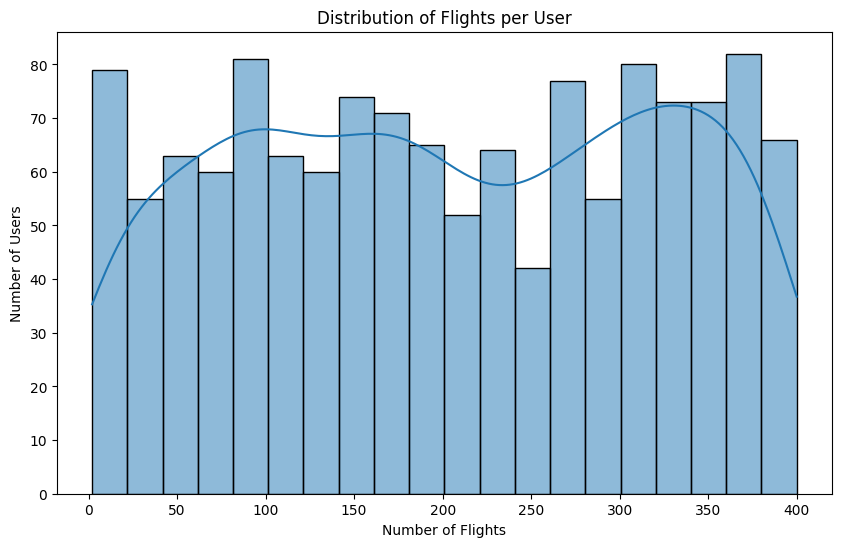

In [64]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=user_profile,
    x="total_flights",
    bins=20,
    kde=True
)

plt.title("Distribution of Flights per User")
plt.xlabel("Number of Flights")
plt.ylabel("Number of Users")

plt.show()

**Gender vs Travel Frequency**

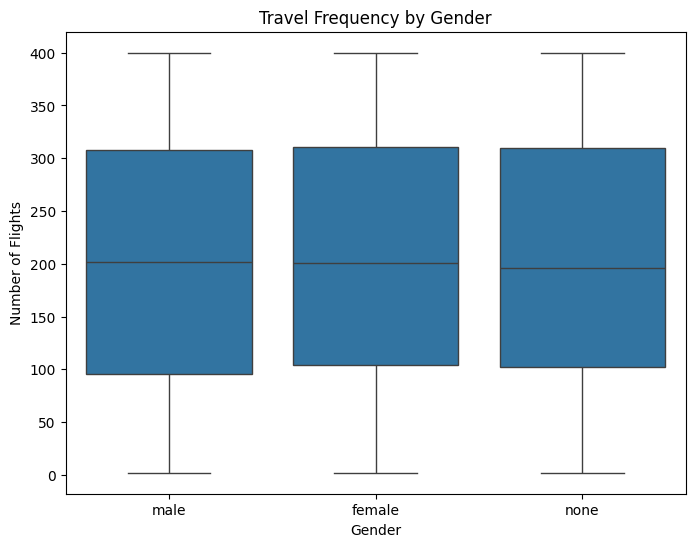

In [65]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=user_profile,
    x="gender",
    y="total_flights"
)

plt.title("Travel Frequency by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Flights")

plt.show()

**Average Flight Price by Gender**

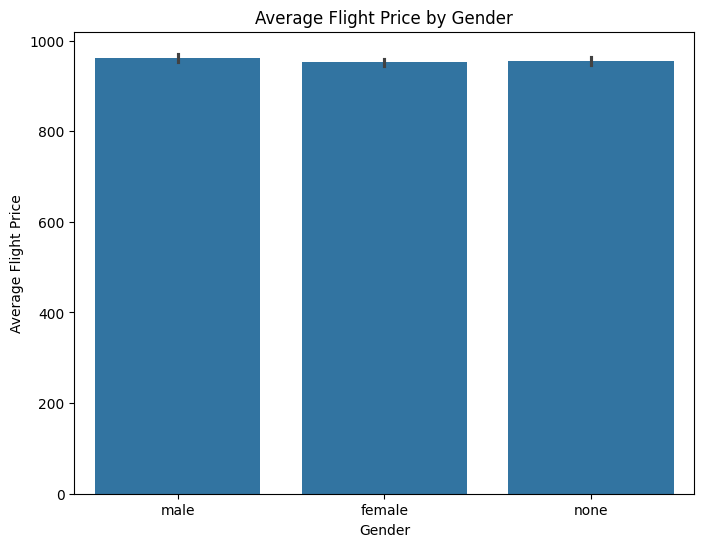

In [67]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=user_profile,
    x="gender",
    y="average_flight_price"
)

plt.title("Average Flight Price by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Flight Price")

plt.show()

## Hypothesis Testing

# 13. Hypothesis Testing

Hypothesis testing is performed to determine whether observed differences or relationships in the travel data are statistically significant.

For each hypothesis:

- Null Hypothesis (H₀): Assumes that there is no significant difference or relationship.
- Alternative Hypothesis (H₁): Assumes that a significant difference or relationship exists.
- Significance Level (α): 0.05

If the p-value is less than 0.05, we reject the null hypothesis.
Otherwise, we fail to reject the null hypothesis.

**Test - 1 Flight Type vs Flight Price**

In [68]:
from scipy import stats

# Remove missing values if any
flight_type_price = flights[["flightType", "price"]].dropna()

# Create groups
groups = [
    group["price"].values
    for _, group in flight_type_price.groupby("flightType")
]

# One-way ANOVA
f_stat, p_value = stats.f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Result: Reject the Null Hypothesis.")
    print("Conclusion: Flight type has a statistically significant relationship with flight price.")
else:
    print("Result: Fail to Reject the Null Hypothesis.")
    print("Conclusion: No statistically significant difference in flight prices was detected across flight types.")

F-statistic: 76521.94535791693
P-value: 0.0
Result: Reject the Null Hypothesis.
Conclusion: Flight type has a statistically significant relationship with flight price.


### Hypothesis 1

**H₀:** The mean flight price is the same across different flight types.

**H₁:** The mean flight price differs across at least one flight type.

**Test Used:** One-Way ANOVA

**Significance Level:** 0.05

The conclusion is based on the p-value obtained from the test.

**Test -2 Distance and Flight Price**

In [69]:
# Pearson correlation test

correlation, p_value = stats.pearsonr(
    flights["distance"],
    flights["price"]
)

print("Pearson Correlation:", correlation)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Result: Reject the Null Hypothesis.")
    print("Conclusion: There is a statistically significant linear relationship between distance and flight price.")
else:
    print("Result: Fail to Reject the Null Hypothesis.")
    print("Conclusion: No statistically significant linear relationship was detected.")

Pearson Correlation: 0.6419153216454515
P-value: 0.0
Result: Reject the Null Hypothesis.
Conclusion: There is a statistically significant linear relationship between distance and flight price.


### Hypothesis 2

**H₀:** There is no statistically significant linear relationship between flight distance and flight price.

**H₁:** There is a statistically significant linear relationship between flight distance and flight price.

**Test Used:** Pearson Correlation Test

**Significance Level:** 0.05

The conclusion is based on the correlation coefficient and p-value.

**Test 3 - Hotel Stay Duration vs Total Price**

In [70]:
# Pearson correlation between hotel stay duration and total price

correlation, p_value = stats.pearsonr(
    hotels["days"],
    hotels["total"]
)

print("Pearson Correlation:", correlation)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Result: Reject the Null Hypothesis.")
    print("Conclusion: There is a statistically significant relationship between stay duration and total hotel price.")
else:
    print("Result: Fail to Reject the Null Hypothesis.")
    print("Conclusion: No statistically significant relationship was detected.")

Pearson Correlation: 0.7528499531112408
P-value: 0.0
Result: Reject the Null Hypothesis.
Conclusion: There is a statistically significant relationship between stay duration and total hotel price.


### Hypothesis 3

**H₀:** There is no statistically significant relationship between hotel stay duration and total booking price.

**H₁:** There is a statistically significant relationship between hotel stay duration and total booking price.

**Test Used:** Pearson Correlation Test

**Significance Level:** 0.05

The conclusion is based on the correlation coefficient and p-value.

**Test 4 — Gender vs Average Flight Price**

In [71]:
# Prepare data

gender_price = user_profile[
    ["gender", "average_flight_price"]
].dropna()

gender_groups = gender_price.groupby("gender")["average_flight_price"]

groups = list(gender_groups)

if len(groups) == 2:
    group1 = groups[0]
    group2 = groups[1]

    t_stat, p_value = stats.ttest_ind(
        group1,
        group2,
        equal_var=False
    )

    print("T-statistic:", t_stat)
    print("P-value:", p_value)

    alpha = 0.05

    if p_value < alpha:
        print("Result: Reject the Null Hypothesis.")
        print("Conclusion: Average flight prices differ significantly between the two gender groups.")
    else:
        print("Result: Fail to Reject the Null Hypothesis.")
        print("Conclusion: No statistically significant difference was detected between the two gender groups.")
else:
    print("This test requires exactly two gender groups.")

This test requires exactly two gender groups.


### Hypothesis 4

**H₀:** The average flight price is the same between the two gender groups.

**H₁:** The average flight price differs between the two gender groups.

**Test Used:** Independent Two-Sample T-Test

**Significance Level:** 0.05

The conclusion is based on the p-value obtained from the test.

# 14. Business Insights

The exploratory analysis of users, flights, and hotels provides several useful business insights.

### User Insights

- The Users dataset provides demographic information such as age, gender, and associated company.
- The distribution of users across demographic categories can help understand the composition of the travel customer base.
- User-level travel summaries allow us to identify differences in travel frequency and average flight spending.

### Flight Insights

- Flight prices show variation across different flight types.
- Flight distance and flight duration are important numerical variables associated with flight pricing and should be considered during regression model development.
- Different flight agencies and routes show variations in flight prices.
- Monthly and weekly analysis can help identify temporal patterns in flight activity and pricing.
- Route-level analysis can help identify expensive travel routes.

### Hotel Insights

- Hotel prices vary across hotels and locations.
- Stay duration is an important factor when analyzing total hotel booking expenditure.
- Popular hotel locations and hotels can be identified from booking frequency.
- Monthly analysis can help identify changes in hotel booking activity and pricing.

### Cross-Dataset Insights

- Users, flights, and hotels are connected through user and travel identifiers.
- Combining these datasets provides a more complete view of customer travel behavior.
- User-level travel profiles can be useful for future personalized hotel recommendation systems.

In [72]:
eda_summary = pd.DataFrame({
    "Dataset": ["Users", "Flights", "Hotels"],
    "Rows": [users.shape[0], flights.shape[0], hotels.shape[0]],
    "Columns": [users.shape[1], flights.shape[1], hotels.shape[1]],
    "Missing Values": [
        users.isnull().sum().sum(),
        flights.isnull().sum().sum(),
        hotels.isnull().sum().sum()
    ],
    "Duplicate Rows": [
        users.duplicated().sum(),
        flights.duplicated().sum(),
        hotels.duplicated().sum()
    ]
})

display(eda_summary)

,Dataset,Rows,Columns,Missing Values,Duplicate Rows
0,Users,1340,5,0,0
1,Flights,271888,14,0,0
2,Hotels,40552,12,0,0


**Important Numerical Relationships**

In [73]:
print("========== FLIGHT PRICE RELATIONSHIPS ==========")

display(
    flights[
        ["price", "time", "distance"]
    ].corr()["price"].sort_values(ascending=False)
)

print("\n========== HOTEL TOTAL PRICE RELATIONSHIPS ==========")

display(
    hotels[
        ["days", "price", "total"]
    ].corr()["total"].sort_values(ascending=False)
)

========== FLIGHT PRICE RELATIONSHIPS ==========


price       1.000000
distance    0.641915
time        0.641800
Name: price, dtype: float64


========== HOTEL TOTAL PRICE RELATIONSHIPS ==========


total    1.00000
days     0.75285
price    0.60273
Name: total, dtype: float64

# EDA Conclusion

# 15. EDA Conclusion

The exploratory data analysis provided an overall understanding of the Users, Flights, and Hotels datasets.

The analysis covered:

- Dataset structure and data types
- Missing-value and duplicate-value analysis
- Numerical and categorical variable distributions
- User demographics
- Flight pricing patterns
- Flight distance and duration
- Flight types and agencies
- Popular origins and destinations
- Hotel pricing
- Hotel stay duration
- Popular hotels and locations
- Monthly travel and booking patterns
- Relationships between the three datasets
- Statistical hypothesis testing

The analysis also helped identify potentially useful variables for subsequent machine learning tasks.

For the flight price prediction problem, variables such as flight type, distance, duration, origin, destination, agency, and date-related features can be investigated during feature engineering.

For the hotel recommendation problem, user travel history, hotel location, hotel characteristics, stay duration, and historical booking information can be considered.

The findings from this EDA will be used as the foundation for the machine learning models developed in the subsequent notebooks.

# 16. Future Work

Based on the findings from the exploratory analysis, the next stages of the project will focus on:

1. Feature engineering and preprocessing.
2. Flight price regression model development.
3. Gender classification model development.
4. Hotel recommendation system development.
5. Model evaluation and comparison.
6. Experiment tracking using MLflow.
7. REST API development using Flask.
8. Containerization using Docker.
9. Scalable deployment using Kubernetes.
10. Workflow automation using Apache Airflow.
11. CI/CD implementation using Jenkins.
12. Development of an interactive Streamlit application.